# Cost calculations for neuro-foundation models

This notebook approximates the costs of building different classes of foundation models for neural activity. One of the key factors in determining the cost is the cost of generation and retention of data. There are three main classes of foundation models: 1) **Exo-X**; 2) **Exo-N/Endo-X**; 3) **Endo-N**. Exo-X class has two subclasses: 1) **Exo-X-simulation**. This subclass uses virtual environments to produce experiential data using GPUs.; 2) **Exo-X-public**. This subclass relies on publicly available data from the internet and online repositories. 

The costs associated with each class falls into the following three categories: 1) **Acquisition**. It includes the upfront cost that needs to be paid in order to enable data collection.; 2) **Curation/Generation**. The labor cost associated with curating and annotating the data or alternatively generate the data in simulation.; 3) **Storage**. The cost associated with storage of the data over the duration of the project. 

The cost subtypes associated with each class is as follows: 

**Acquisition**: 
Exo-N/Endo-X and Exo-N require acquisition of a microscope/electrophysioly setup, animal subjects, supporting costs. 
Equal proportion of mouse and macaque subjects are assumed. Each mouse and macaque subject is assumed to contribute to 100 and 1000 hours of data collection respectivley. 

For Endo models:
- 2-photon microscope system construction cost: $750k ($400k-$1million)
- 2-photon microscope lifetime 40,000 hours
- Mouse purchase cost: $130 / animal 
- Macaque monkey purchase cost: $30k / animal 
- Rig + support (surgical tools, acquisition equipment): $100k for 10,000 hours of recording. 
- Animal care cost: $4 /animal/day
- 50% of data collection uses imaging, the rest for electrophysiology

For Exo models: 
- Data generation rate: 10 units/sec/gpu
- GPU cost: $2 /hr/gpu


**Curation**: 
1. Exo-X. Exo-X-simulation requires GPUs to generate and if necessary annotate the data. The cost is calcualted per GPU per hour considering the rate of data production. Exo-X-public requires curation of experintial datasets which introduces labor cost.

2. Exo-N and Exo-N/Endo-X. Require labor costs for collecting neural data, curating different neural datasets. 

**Storage**: 
All classes except Exo-X-simulation require data storage costs calculated monthly according to the number of data points. For each approach the per data point storage size can be calcluated and the monthly storage cost as a function of number of data points is calculated. One data point is considered as ten second of activity collected from an information stream. Exo-N/Endo-X data consists of equal number of experiential and neural data points. The experiential data is assumed to consist of 60% text, 20% video, and 20% images.


*Per unit data size*:
Video data: 1 second of 1080p colored video (1080p resolution, 30 fps, H.264: 6.22 MB)
Image data: 1 500px500p Jpeg (0.1 MB) 
Text data: 1 character (4 Bytes)
Electrophysiology and imaging: 1 second of 1000 sites (0.02 MB; assuming spike storage size of 2 B/spike and average spike frequency of 10Hz). 

*Labor*:
Labor cost for data collection and curation: $40/hr 
Neural data curation rate: 1000 data point/hr
Experience data curation rate: 10000 data point/hr (experiential data points are of much larger size than neural datasets and so the labor rate is estimated lower)

Cloud-based storage cost: 0.023/GB/month


In [1]:
import numpy as np
import matplotlib.pyplot as plt
# -----------------------------
# Parameters
# -----------------------------
params = {
    'labor_cost_per_hr': 40.0,
    'neural_curation_rate_pts_per_hr': 1000.0,
    'experience_curation_rate_pts_per_hr': 10000.0,
    'gpu_gen_rate_pts_per_sec': 10.0,
    'gpu_cost_per_hr': 2.0,
    'storage_cost_per_gb_month': 0.023,
    'bytes_per_point': {
        'video': 6.22 * 1024**2 * 10,   # 10s per data point
        'image': 0.1 * 1024**2,
        'text': 4.0,
        'neural': 0.02 * 1024**2 * 10,  # 10s per data point
    },
    'mouse_hour_fraction': 0.5,
}
hardware = {
    'two_photon_cost': 750_000.0,
    'two_photon_hours_capacity': 40000.0,
    'rig_support_cost': 100000.0,
    'rig_support_hours_capacity': 10000.0,
    'mouse_cost': 130.0,
    'mouse_hours_capacity': 100.0,
    'macaque_cost': 30000.0,
    'macaque_hours_capacity': 1000.0,
}
per_diem = {
    'rate_per_day': 4.0,
    'apply': True,
}
# Define data modality mix per class (fractions sum to 1.0)
data_mix = {
    'Exo-X-simulation': {'text': 0.6, 'video': 0.2, 'image': 0.2},
    'Exo-X-public': {'text': 0.6, 'video': 0.2, 'image': 0.2},
    'Exo-N/Endo-X': {'neural': 1.0, 'text': 0.6, 'video': 0.2, 'image': 0.2}, # The ratios add up to 2.0 because in Exo-N/Endo-X both the experiential and neural data need to be collected and stored.
    'Endo-N': {'neural': 1.0},
}
classes = ['Exo-X-simulation', 'Exo-X-public', 'Exo-N/Endo-X', 'Endo-N']
# -----------------------------
# Cost functions
# -----------------------------
def storage_cost_per_point_per_month(mix, params):
    bytes_per_point = 0.0
    for modality, frac in mix.items():
        bytes_per_point += frac * params['bytes_per_point'][modality]
    gb_per_point = bytes_per_point / (1024**3)
    return gb_per_point * params['storage_cost_per_gb_month']

def curation_cost_per_point(class_name, params):
    if class_name == 'Exo-X-simulation':
        pts_per_hr = params['gpu_gen_rate_pts_per_sec'] * 3600.0
        return params['gpu_cost_per_hr'] / pts_per_hr
    if class_name == 'Exo-X-public':
        return params['labor_cost_per_hr'] / params['experience_curation_rate_pts_per_hr']
    if class_name == 'Exo-N/Endo-X':
        # Exo-N/Endo-X has both neural and experiential data; equal weighting
        neural_cost = params['labor_cost_per_hr'] / params['neural_curation_rate_pts_per_hr']
        experiential_cost = params['labor_cost_per_hr'] / params['experience_curation_rate_pts_per_hr']
        return neural_cost + experiential_cost
    # For Endo-N, only neural data
    return params['labor_cost_per_hr'] / params['neural_curation_rate_pts_per_hr']

def acquisition_cost_neural(n_neural_points, months, params, hardware, per_diem):
    # Each data point = 10 seconds of recording
    hours_needed = n_neural_points * 10 / 3600.0
    # Split between mouse and macaque hours
    mouse_hours = hours_needed * params['mouse_hour_fraction']
    macaque_hours = hours_needed * (1.0 - params['mouse_hour_fraction'])
    mice_needed = np.ceil(np.maximum(mouse_hours, 0.0) / hardware['mouse_hours_capacity'])
    macaques_needed = np.ceil(np.maximum(macaque_hours, 0.0) / hardware['macaque_hours_capacity'])
    # Equal split between imaging and ephys
    imaging_hours = hours_needed / 2.0
    microscopes_needed = np.ceil(np.maximum(imaging_hours, 0.0) / hardware['two_photon_hours_capacity'])
    rigs_needed = np.ceil(np.maximum(hours_needed, 0.0) / hardware['rig_support_hours_capacity'])
    base_cost = (
        mice_needed * hardware['mouse_cost'] +
        macaques_needed * hardware['macaque_cost'] +
        microscopes_needed * hardware['two_photon_cost'] +
        rigs_needed * hardware['rig_support_cost']
    )
    if per_diem['apply']:
        days = months * 30.0
        per_diem_cost = (mice_needed + macaques_needed) * per_diem['rate_per_day'] * days
    else:
        per_diem_cost = 0.0
    return base_cost + per_diem_cost

def total_cost(class_name, n_points, months, params, data_mix, hardware, per_diem):
    if class_name == 'Exo-X-simulation':
        storage = 0.0
    else:
        storage_per_point_per_month = storage_cost_per_point_per_month(data_mix[class_name], params)
        storage = storage_per_point_per_month * (n_points) * months
    curation_per_point = curation_cost_per_point(class_name, params)
    curation = curation_per_point * n_points
    if class_name in ('Exo-N/Endo-X', 'Endo-N'):
        acquisition = acquisition_cost_neural(n_points, months, params, hardware, per_diem)
    else:
        acquisition = 0.0
    return acquisition + curation + storage


In [2]:
# Figure styling for publication-quality neuroscience plots
import matplotlib as mpl

mpl.rcParams.update({
    'figure.dpi': 160,
    'savefig.dpi': 400,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'Liberation Sans',  # metrically identical to Arial; Arial itself is not installed
    'font.size': 20,
    'axes.titlesize': 17,
    'axes.labelsize': 20,
    'axes.labelweight': 'regular',
    'axes.linewidth': 0.9,
    'axes.titlepad': 10,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'xtick.major.size': 3.5,
    'ytick.major.size': 3.5,
    'xtick.major.width': 0.9,
    'ytick.major.width': 0.9,
    'legend.fontsize': 16,
    'legend.frameon': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

CLASS_COLORS = {
    'Exo-X-simulation': '#0072B2',
    'Exo-X-public': '#009E73',
    'Exo-N/Endo-X': '#D55E00',
    'Endo-N': '#CC79A7',
}

def style_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4, width=1)
    ax.grid(False)

    # trim bottom/left spines to first and last visible major ticks
    xt = ax.get_xticks()
    yt = ax.get_yticks()

    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()

    xt = xt[(xt >= x0) & (xt <= x1)]
    yt = yt[(yt >= y0) & (yt <= y1)]
    ax.spines['bottom'].set_bounds(xt[0], xt[-1])
    ax.spines['left'].set_bounds(yt[0], yt[-1])

def style_3d(ax):
    ax.grid(False)
    # Remove heavy panes/grids to match clean journal look
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor((1, 1, 1, 0))
        axis.pane.set_edgecolor((1, 1, 1, 0))
        axis._axinfo['grid']['linewidth'] = 0
    ax.tick_params(axis='both', which='major', direction='out', pad=2)

def add_surface_legend(ax):
    handles = [
        plt.Line2D([0], [0], color=CLASS_COLORS[name], lw=3, label=name)
        for name in ['Exo-X-simulation', 'Exo-X-public', 'Exo-N/Endo-X', 'Endo-N']
    ]
    ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(0.05, 0.8))


# Grid + plot

In [3]:
# %matplotlib widget

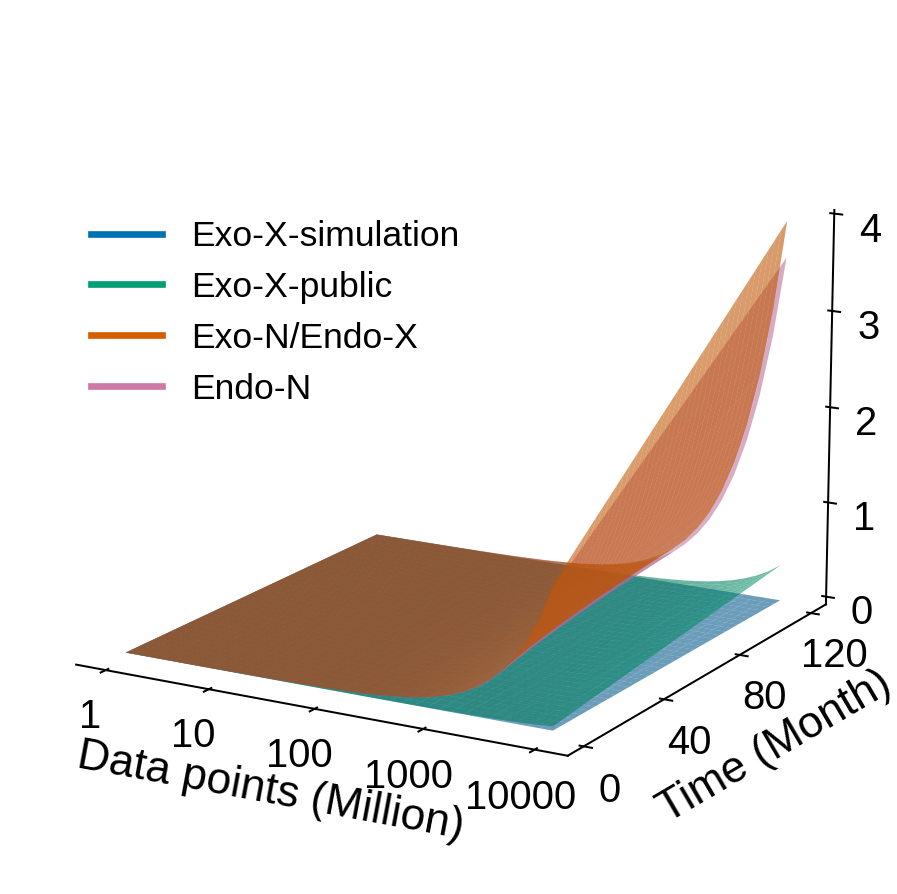

In [12]:
n_points_grid = np.logspace(6, 10, 36)
months_grid = np.linspace(1, 120, 36)
N, T = np.meshgrid(n_points_grid, months_grid)

# mplot3d does not support true log x scaling for surfaces, so transform explicitly
X = np.log10(N)

# constrained_layout is incompatible with 3D axes and causes edge clipping
fig = plt.figure(figsize=(12.0, 7.0))
ax = fig.add_subplot(111, projection='3d')

for class_name in classes:
    Z = total_cost(class_name, N, T, params, data_mix, hardware, per_diem) / 1e9
    ax.plot_surface(
        X, T, Z,
        alpha=0.58,
        linewidth=0,
        antialiased=True,
        color=CLASS_COLORS[class_name],
        shade=True,
    )

ax.set_xlabel('Data points (Million)', labelpad=8)
ax.set_ylabel('Time (Month)', labelpad=8)
ax.set_zlabel('Cost (Billion USD)', labelpad=10)
ax.view_init(elev=15, azim=-60)

# Ticks at log10 positions, labeled in billions
ax.xaxis.set_ticks(np.arange(6, 11, 1))
ax.xaxis.set_ticklabels(['1', '10', '100', '1000', '10000'])
ax.yaxis.set_ticks(np.arange(0, 121, 40))  # every 40 months
style_3d(ax)
add_surface_legend(ax,)

plt.savefig('cost_vs_data_points_and_time_surface.pdf', bbox_inches='tight', pad_inches=0.5)
plt.show()


In [5]:
%matplotlib inline

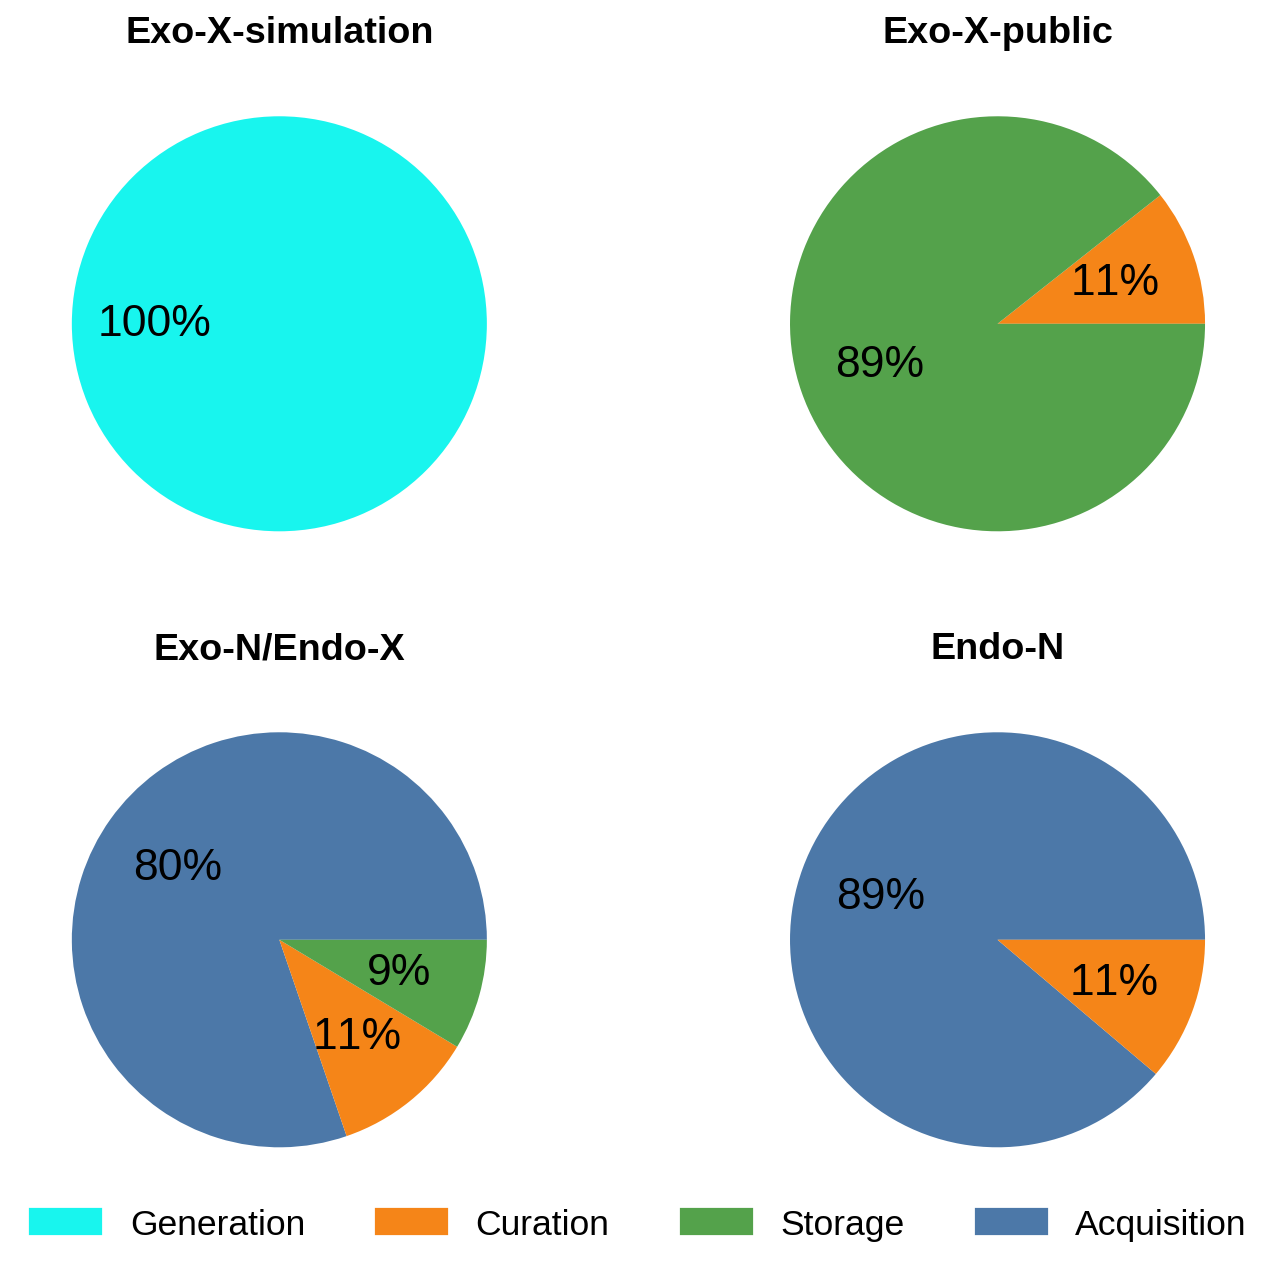

In [62]:
# Pie charts of cost breakdown by class
import matplotlib.patches as mpatches

n_points_pie = 1e9
months_pie = 120

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

colors = {
    'Acquisition': '#4C78A8',
    'Curation': '#F58518',
    'Generation': "#18F5EE",
    'Storage': '#54A24B',
}

legend_handles = {}

for ax, class_name in zip(axes, classes):
    # storage
    if class_name == 'Exo-X-simulation':
        storage = 0.0
    else:
        storage_ppm = storage_cost_per_point_per_month(data_mix[class_name], params)
        storage = storage_ppm * n_points_pie * months_pie

    # curation
    curation_pp = curation_cost_per_point(class_name, params)
    curation = curation_pp * n_points_pie

    # acquisition
    if class_name in ('Exo-N/Endo-X', 'Endo-N'):
        n_neural_points = n_points_pie * data_mix[class_name].get('neural', 0.0)
        acquisition = acquisition_cost_neural(n_neural_points, months_pie, params, hardware, per_diem)
    else:
        acquisition = 0.0

    values = [acquisition, curation, storage]

    # Use 'Generation' label for Exo-X-simulation, 'Curation' for others
    class_labels = ['Acquisition', 'Generation' if class_name == 'Exo-X-simulation' else 'Curation', 'Storage']

    total = sum(values)
    keep = [(v, l) for v, l in zip(values, class_labels) if total > 0 and (v / total) >= 0.01]
    if keep:
        values_plot, labels_plot = zip(*keep)
        colors_plot = [colors[l] for l in labels_plot]
    else:
        values_plot, labels_plot, colors_plot = [0.0], ['No costs'], ['#B0B0B0']

    ax.pie(
        values_plot,
        labels=None,
        autopct='%1.0f%%',
        colors=colors_plot,
        pctdistance=0.6,
    )

    for label, color in zip(labels_plot, colors_plot):
        if label not in legend_handles:
            legend_handles[label] = mpatches.Patch(color=color, label=label)

    ax.set_title(class_name, fontweight='bold')
    ax.set_aspect('equal')

fig.legend(
    handles=list(legend_handles.values()),
    loc='lower center',
    ncol=len(legend_handles),
    bbox_to_anchor=(0.5, -0.02),
    frameon=False,
)

plt.tight_layout()
plt.savefig('cost_breakdown_pie_charts.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [8]:
%matplotlib inline

In [10]:
# Storage cost vs time for 1e9 points across classes
# n_points = 1e9
# months = np.linspace(1, 120, 24)

# fig, ax = plt.subplots(figsize=(8, 5))

# for class_name in classes: #  ['Exo-N'] classes
#     storage_per_point_per_month = storage_cost_per_point_per_month(data_mix[class_name], params)
#     storage = storage_per_point_per_month * n_points * months
#     ax.plot(months, storage, label=class_name, marker='o')
#     # ax.set_yscale('log')
#     # ax.set_xscale('log')

# ax.set_xlabel('Time (months)')
# ax.set_ylabel('Storage cost (USD)')
# ax.set_title('Storage cost for 1e9 data points')
# ax.legend(title='Class')
# style_axes(ax)

# plt.tight_layout()
# plt.savefig('storage_cost_vs_time.pdf', dpi=300, bbox_inches='tight')
# plt.show()


In [28]:
%matplotlib inline

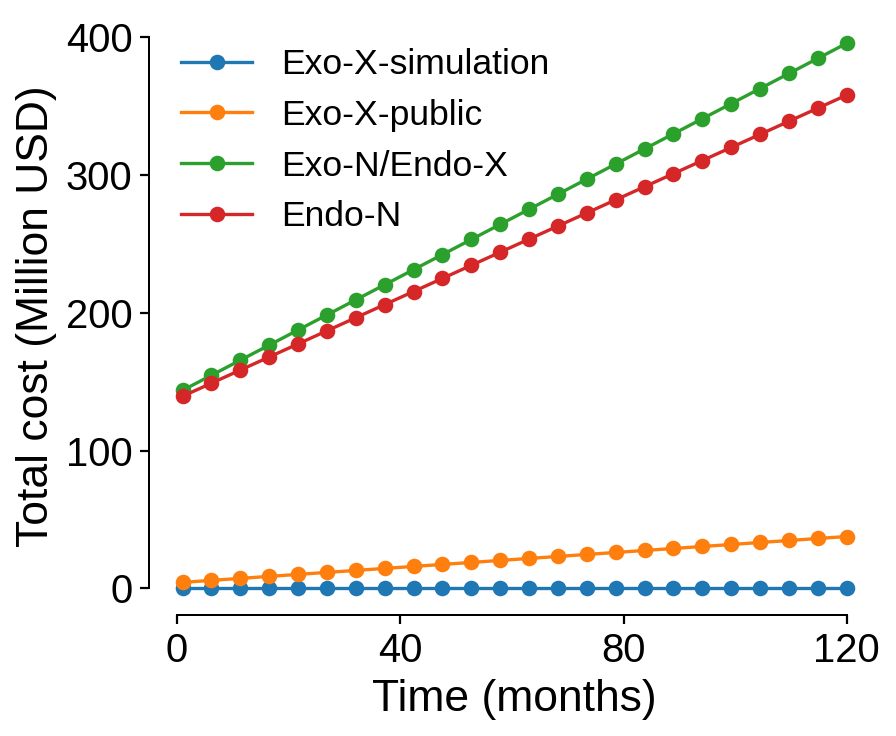

In [71]:
# Total cost vs time for 1e9 points across classes
months = np.linspace(1, 120, 24)
n_points = np.ones(24) * 1e9

fig, ax = plt.subplots(figsize=(6, 5))

for class_name in classes:
    Z = total_cost(class_name, n_points, months, params, data_mix, hardware, per_diem) / 1e6
    ax.plot(months, Z, label=class_name, marker='o')
    # ax.set_yscale('log')

ax.set_xlabel('Time (months)')
ax.set_ylabel('Total cost (Million USD)')
ax.xaxis.set_ticks(np.arange(0, 121, 40))  # every 40 months
# ax.set_title('Total cost for 1e9 data points')
ax.legend()
style_axes(ax)
plt.tight_layout()
plt.savefig('total_cost_vs_time.pdf', dpi=300, bbox_inches='tight')
plt.show()

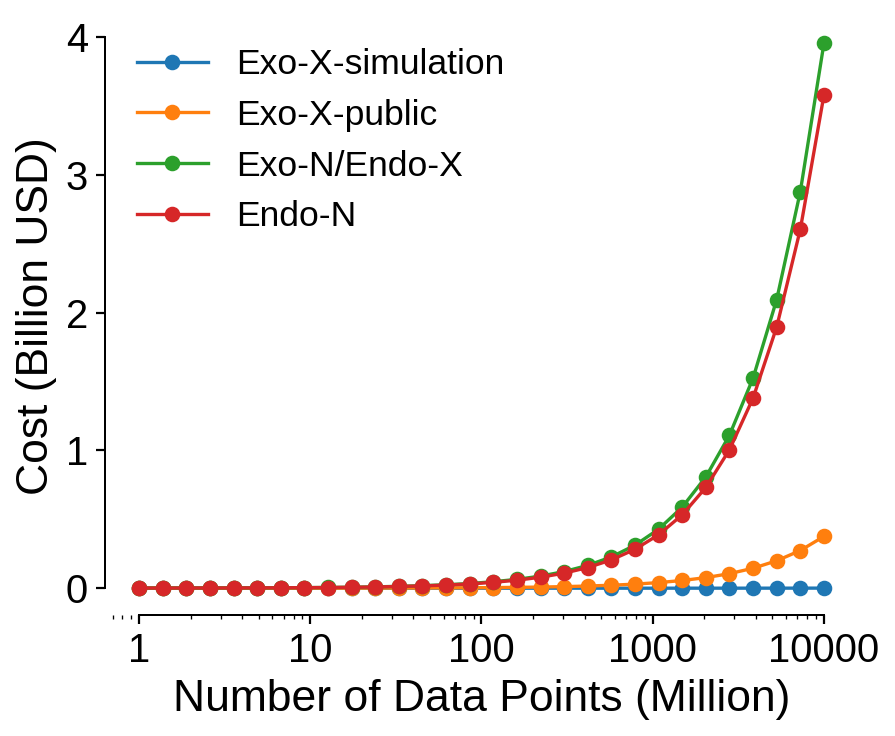

In [3]:
# Cost vs data points at 120 months
months_fixed = 120
n_points_grid_1d = np.logspace(6, 10, 30)

fig, ax = plt.subplots(figsize=(6, 5))

for class_name in classes:
    Z = total_cost(class_name, n_points_grid_1d, months_fixed, params, data_mix, hardware, per_diem) / 1e9
    ax.plot(n_points_grid_1d, Z, label=class_name, marker='o')

ax.set_xscale('log')
ax.set_xlabel('Number of Data Points (Million)')
ax.set_ylabel('Cost (Billion USD)')
# ax.set_title('Cost vs data points at 12 months')
ax.legend()
ax.xaxis.set_ticks(np.logspace(6, 10, 5))
ax.xaxis.set_ticklabels(['1', '10', '100', '1000', '10000'])
style_axes(ax)
plt.tight_layout()
plt.savefig('cost_vs_data_points.pdf', dpi=300, bbox_inches='tight')
plt.show()
